# **Project Name**    -



##### **Project Type**    - EDA/Regression/Classification/Unsupervised
##### **Contribution**    - Individual/Team
##### **Team Member 1 -**
##### **Team Member 2 -**
##### **Team Member 3 -**
##### **Team Member 4 -**

# **Project Summary -**

The Brain Tumor MRI Image Classification project is a deep learning-based image classification system designed to classify brain MRI images into different tumor categories. The project uses Python and TensorFlow/Keras for image preprocessing, model development, training, and evaluation.

The project follows a complete machine-learning workflow, starting with understanding the MRI dataset and its different categories. The images are preprocessed by resizing them to a consistent size and normalizing pixel values. Data augmentation techniques such as rotation, flipping, zooming, brightness adjustment, and shifting can be used to improve the model's ability to generalize to new MRI images.

Three deep learning models were developed for comparison: Custom CNN, MobileNetV2, and EfficientNetB0. The Custom CNN uses convolutional layers, pooling, batch normalization, and dropout to learn important image features. MobileNetV2 and EfficientNetB0 use transfer learning with pretrained ImageNet models, allowing the system to make use of previously learned image features.

The models are evaluated using Accuracy, Precision, Recall, and F1-Score. Confusion matrices and training-history graphs can also be used to understand model performance. Hyperparameter tuning was performed to improve model performance by testing different configurations such as learning rate, dropout, and dense-layer units.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


Brain tumor diagnosis from MRI images can be difficult and time-consuming when performed manually. The problem is to develop a deep learning-based image classification system that can automatically classify brain MRI images into multiple tumor categories. The system will use Custom CNN and transfer-learning models such as MobileNetV2 and EfficientNetB0, evaluate their performance, and provide predictions for new MRI images.

#### **Define Your Business Objective?**

. Reduce the time required for initial MRI image classification.
. Automatically identify the likely tumor category from an uploaded MRI image.
. Compare Custom CNN and pretrained models such as MobileNetV2 and EfficientNetB0.
. Evaluate model performance using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.
. Deploy the selected trained model through a Streamlit web application for easy image upload and prediction.
. Provide prediction confidence to support the result.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# IMPORT LIBRARIES
# ============================================================

# -----------------------------
# 1. Basic Libraries
# -----------------------------
import os
import warnings
import json

# -----------------------------
# 2. Numerical & Data Handling
# -----------------------------
import numpy as np
import pandas as pd

# -----------------------------
# 3. Visualization
# -----------------------------
import matplotlib.pyplot as plt

# -----------------------------
# 4. Image Processing
# -----------------------------
from PIL import Image

# -----------------------------
# 5. TensorFlow / Keras
# -----------------------------
import tensorflow as tf
from tensorflow import keras

# -----------------------------
# 6. Keras Layers
# -----------------------------
from tensorflow.keras import layers

from tensorflow.keras.models import Sequential, Model

from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)

# -----------------------------
# 7. Image Augmentation
# -----------------------------
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.utils import image_dataset_from_directory

# -----------------------------
# 8. Transfer Learning Models
# -----------------------------
from tensorflow.keras.applications import (
    ResNet50,
    MobileNetV2,
    InceptionV3,
    EfficientNetB0
)

# -----------------------------
# 9. Training Callbacks
# -----------------------------
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

# -----------------------------
# 10. Warnings
# -----------------------------
warnings.filterwarnings("ignore")

# ============================================================
# CHECK
# ============================================================

print("=" * 60)
print("BRAIN TUMOR MRI IMAGE CLASSIFICATION")
print("=" * 60)

print("TensorFlow Version:", tf.__version__)
print("NumPy Version:", np.__version__)
print("Pandas Version:", pd.__version__)

print("=" * 60)
print("✅ ALL REQUIRED BASIC LIBRARIES IMPORTED SUCCESSFULLY")
print("=" * 60)

BRAIN TUMOR MRI IMAGE CLASSIFICATION
TensorFlow Version: 2.22.0-rc0
NumPy Version: 2.4.6
Pandas Version: 2.3.3
✅ ALL REQUIRED BASIC LIBRARIES IMPORTED SUCCESSFULLY


### Dataset Loading

In [2]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# DATASET LOADING
# ============================================================

import os
import pandas as pd

# ------------------------------------------------------------
# 1. Main Dataset Path
# ------------------------------------------------------------

base_path = r"C:\Users\Admin\OneDrive\Desktop\BRAIN TUMOR"

# ------------------------------------------------------------
# 2. Train / Validation / Test Paths
# ------------------------------------------------------------

train_path = os.path.join(
    base_path,
    "train-20260930T101539Z-1-001",
    "train"
)

valid_path = os.path.join(
    base_path,
    "valid-20260930T172018Z-1-001",
    "valid"
)

test_path = os.path.join(
    base_path,
    "test-20260930T171957Z-1-001",
    "test"
)

# ------------------------------------------------------------
# 3. Check Folders
# ------------------------------------------------------------

print("=" * 60)
print("BRAIN TUMOR MRI DATASET")
print("=" * 60)

print("Train folder      :", os.path.exists(train_path))
print("Validation folder :", os.path.exists(valid_path))
print("Test folder       :", os.path.exists(test_path))

# ------------------------------------------------------------
# 4. Find CSV Automatically
# ------------------------------------------------------------

def find_csv(folder):
    csv_files = []

    for file in os.listdir(folder):
        if file.lower().endswith(".csv"):
            csv_files.append(file)

    if len(csv_files) == 0:
        return None

    return os.path.join(folder, csv_files[0])


train_csv = find_csv(train_path)
valid_csv = find_csv(valid_path)
test_csv = find_csv(test_path)

print("\nCSV FILES")
print("-" * 60)

print("Train CSV      :", train_csv)
print("Validation CSV :", valid_csv)
print("Test CSV       :", test_csv)

# ------------------------------------------------------------
# 5. Load CSV Files
# ------------------------------------------------------------

train_df = pd.read_csv(train_csv)
valid_df = pd.read_csv(valid_csv)
test_df = pd.read_csv(test_csv)

# ------------------------------------------------------------
# 6. Dataset Information
# ------------------------------------------------------------

print("\nDATASET INFORMATION")
print("-" * 60)

print("Training samples   :", len(train_df))
print("Validation samples :", len(valid_df))
print("Testing samples    :", len(test_df))

print("\nTrain shape      :", train_df.shape)
print("Validation shape :", valid_df.shape)
print("Test shape       :", test_df.shape)

# ------------------------------------------------------------
# 7. Display Columns
# ------------------------------------------------------------

print("\nTRAIN COLUMNS")
print("-" * 60)

for column in train_df.columns:
    print(column)

# ------------------------------------------------------------
# 8. Display First 5 Rows
# ------------------------------------------------------------

print("\nFIRST 5 TRAIN RECORDS")
print("-" * 60)

display(train_df.head())

print("\n" + "=" * 60)
print("✅ DATASET LOADED SUCCESSFULLY")
print("=" * 60)

BRAIN TUMOR MRI DATASET
Train folder      : True
Validation folder : True
Test folder       : True

CSV FILES
------------------------------------------------------------
Train CSV      : C:\Users\Admin\OneDrive\Desktop\BRAIN TUMOR\train-20260930T101539Z-1-001\train\_classes.csv
Validation CSV : C:\Users\Admin\OneDrive\Desktop\BRAIN TUMOR\valid-20260930T172018Z-1-001\valid\_classes.csv
Test CSV       : C:\Users\Admin\OneDrive\Desktop\BRAIN TUMOR\test-20260930T171957Z-1-001\test\_classes.csv

DATASET INFORMATION
------------------------------------------------------------
Training samples   : 1695
Validation samples : 502
Testing samples    : 246

Train shape      : (1695, 5)
Validation shape : (502, 5)
Test shape       : (246, 5)

TRAIN COLUMNS
------------------------------------------------------------
filename
 Glioma
 Meningioma
 No Tumor
 Pituitary

FIRST 5 TRAIN RECORDS
------------------------------------------------------------


,filename,Glioma,Meningioma,No Tumor,Pituitary
0,Tr-pi_0164_jpg.rf.000776527ec0acdc89e31e15a352...,0,0,0,1
1,Tr-no_0426_jpg.rf.0026b06f369c5d51aca4c4c9beba...,0,0,1,0
2,Tr-gl_0496_jpg.rf.010620fbbbaa509aa81d7ce5bdf7...,1,0,0,0
3,Tr-gl_0554_jpg.rf.010a72c1c25cc9ce83c77fbb23db...,1,0,0,0
4,Tr-me_0185_jpg.rf.0094b0b539582e2f95ae7b6ada4d...,0,1,0,0



✅ DATASET LOADED SUCCESSFULLY


### Dataset First View

In [3]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# DATASET FIRST VIEW
# ============================================================

print("=" * 70)
print("BRAIN TUMOR MRI DATASET - FIRST VIEW")
print("=" * 70)

# ------------------------------------------------------------
# 1. Dataset shapes
# ------------------------------------------------------------
print("\n1. DATASET SHAPE")
print("-" * 70)

print("Training data   :", train_df.shape)
print("Validation data :", valid_df.shape)
print("Testing data    :", test_df.shape)


# ------------------------------------------------------------
# 2. Column names
# ------------------------------------------------------------
print("\n2. COLUMN NAMES")
print("-" * 70)

print("Training columns:")
for col in train_df.columns:
    print(" -", col)


# ------------------------------------------------------------
# 3. First 5 rows
# ------------------------------------------------------------
print("\n3. FIRST 5 TRAINING RECORDS")
print("-" * 70)

print(train_df.head())


# ------------------------------------------------------------
# 4. Last 5 rows
# ------------------------------------------------------------
print("\n4. LAST 5 TRAINING RECORDS")
print("-" * 70)

print(train_df.tail())


# ------------------------------------------------------------
# 5. Data types
# ------------------------------------------------------------
print("\n5. DATA TYPES")
print("-" * 70)

print(train_df.dtypes)


# ------------------------------------------------------------
# 6. Missing values
# ------------------------------------------------------------
print("\n6. MISSING VALUES")
print("-" * 70)

print(train_df.isnull().sum())


# ------------------------------------------------------------
# 7. Number of unique values
# ------------------------------------------------------------
print("\n7. UNIQUE VALUES IN EACH COLUMN")
print("-" * 70)

print(train_df.nunique())


# ------------------------------------------------------------
# 8. Basic statistical information
# ------------------------------------------------------------
print("\n8. BASIC STATISTICS")
print("-" * 70)

print(train_df.describe(include="all"))


print("\n" + "=" * 70)
print("✅ DATASET FIRST VIEW COMPLETED")
print("=" * 70)# Dataset First Look

BRAIN TUMOR MRI DATASET - FIRST VIEW

1. DATASET SHAPE
----------------------------------------------------------------------
Training data   : (1695, 5)
Validation data : (502, 5)
Testing data    : (246, 5)

2. COLUMN NAMES
----------------------------------------------------------------------
Training columns:
 - filename
 -  Glioma
 -  Meningioma
 -  No Tumor
 -  Pituitary

3. FIRST 5 TRAINING RECORDS
----------------------------------------------------------------------
                                            filename   Glioma   Meningioma  \
0  Tr-pi_0164_jpg.rf.000776527ec0acdc89e31e15a352...        0            0   
1  Tr-no_0426_jpg.rf.0026b06f369c5d51aca4c4c9beba...        0            0   
2  Tr-gl_0496_jpg.rf.010620fbbbaa509aa81d7ce5bdf7...        1            0   
3  Tr-gl_0554_jpg.rf.010a72c1c25cc9ce83c77fbb23db...        1            0   
4  Tr-me_0185_jpg.rf.0094b0b539582e2f95ae7b6ada4d...        0            1   

    No Tumor   Pituitary  
0          0           1 

### Dataset Rows & Columns count

In [4]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# DATASET ROWS & COLUMNS COUNT
# ============================================================

print("=" * 60)
print("DATASET ROWS & COLUMNS COUNT")
print("=" * 60)

# Training dataset
print("\nTRAINING DATASET")
print("-" * 60)
print("Rows    :", train_df.shape[0])
print("Columns :", train_df.shape[1])

# Validation dataset
print("\nVALIDATION DATASET")
print("-" * 60)
print("Rows    :", valid_df.shape[0])
print("Columns :", valid_df.shape[1])

# Testing dataset
print("\nTESTING DATASET")
print("-" * 60)
print("Rows    :", test_df.shape[0])
print("Columns :", test_df.shape[1])

# Combined count
total_rows = len(train_df) + len(valid_df) + len(test_df)

print("\nTOTAL DATASET")
print("-" * 60)
print("Total Rows :", total_rows)
print("Columns in Training CSV :", train_df.shape[1])

print("\n" + "=" * 60)
print("✅ ROWS & COLUMNS COUNT COMPLETED")
print("=" * 60)# Dataset Rows & Columns count

DATASET ROWS & COLUMNS COUNT

TRAINING DATASET
------------------------------------------------------------
Rows    : 1695
Columns : 5

VALIDATION DATASET
------------------------------------------------------------
Rows    : 502
Columns : 5

TESTING DATASET
------------------------------------------------------------
Rows    : 246
Columns : 5

TOTAL DATASET
------------------------------------------------------------
Total Rows : 2443
Columns in Training CSV : 5

✅ ROWS & COLUMNS COUNT COMPLETED


### Dataset Information

In [5]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# DATASET INFORMATION
# ============================================================

print("=" * 70)
print("BRAIN TUMOR MRI DATASET INFORMATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Training Dataset Information
# ------------------------------------------------------------
print("\n1. TRAINING DATASET")
print("-" * 70)

print("Rows       :", train_df.shape[0])
print("Columns    :", train_df.shape[1])
print("Memory     :", round(train_df.memory_usage(deep=True).sum() / 1024**2, 2), "MB")


# ------------------------------------------------------------
# 2. Validation Dataset Information
# ------------------------------------------------------------
print("\n2. VALIDATION DATASET")
print("-" * 70)

print("Rows       :", valid_df.shape[0])
print("Columns    :", valid_df.shape[1])
print("Memory     :", round(valid_df.memory_usage(deep=True).sum() / 1024**2, 2), "MB")


# ------------------------------------------------------------
# 3. Testing Dataset Information
# ------------------------------------------------------------
print("\n3. TESTING DATASET")
print("-" * 70)

print("Rows       :", test_df.shape[0])
print("Columns    :", test_df.shape[1])
print("Memory     :", round(test_df.memory_usage(deep=True).sum() / 1024**2, 2), "MB")


# ------------------------------------------------------------
# 4. Column Information
# ------------------------------------------------------------
print("\n4. TRAINING COLUMN INFORMATION")
print("-" * 70)

print(train_df.info())


# ------------------------------------------------------------
# 5. Missing Values
# ------------------------------------------------------------
print("\n5. MISSING VALUES")
print("-" * 70)

missing_values = train_df.isnull().sum()

print(missing_values)


# ------------------------------------------------------------
# 6. Duplicate Rows
# ------------------------------------------------------------
print("\n6. DUPLICATE ROWS")
print("-" * 70)

print("Duplicate rows :", train_df.duplicated().sum())


# ------------------------------------------------------------
# 7. Data Types
# ------------------------------------------------------------
print("\n7. DATA TYPES")
print("-" * 70)

print(train_df.dtypes)


print("\n" + "=" * 70)
print("✅ DATASET INFORMATION COMPLETED")
print("=" * 70)# Dataset Info

BRAIN TUMOR MRI DATASET INFORMATION

1. TRAINING DATASET
----------------------------------------------------------------------
Rows       : 1695
Columns    : 5
Memory     : 0.22 MB

2. VALIDATION DATASET
----------------------------------------------------------------------
Rows       : 502
Columns    : 5
Memory     : 0.06 MB

3. TESTING DATASET
----------------------------------------------------------------------
Rows       : 246
Columns    : 5
Memory     : 0.03 MB

4. TRAINING COLUMN INFORMATION
----------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1695 entries, 0 to 1694
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   filename     1695 non-null   object
 1    Glioma      1695 non-null   int64 
 2    Meningioma  1695 non-null   int64 
 3    No Tumor    1695 non-null   int64 
 4    Pituitary   1695 non-null   int64 
dtypes: int64(4), object(1)
mem

#### Duplicate Values

In [6]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# DUPLICATE VALUES CHECK
# ============================================================

print("=" * 60)
print("DUPLICATE VALUES CHECK")
print("=" * 60)

# ------------------------------------------------------------
# 1. Training Dataset
# ------------------------------------------------------------
train_duplicates = train_df.duplicated().sum()

print("\nTRAINING DATASET")
print("-" * 60)
print("Total rows       :", len(train_df))
print("Duplicate rows   :", train_duplicates)
print("Unique rows      :", len(train_df) - train_duplicates)


# ------------------------------------------------------------
# 2. Validation Dataset
# ------------------------------------------------------------
valid_duplicates = valid_df.duplicated().sum()

print("\nVALIDATION DATASET")
print("-" * 60)
print("Total rows       :", len(valid_df))
print("Duplicate rows   :", valid_duplicates)
print("Unique rows      :", len(valid_df) - valid_duplicates)


# ------------------------------------------------------------
# 3. Testing Dataset
# ------------------------------------------------------------
test_duplicates = test_df.duplicated().sum()

print("\nTESTING DATASET")
print("-" * 60)
print("Total rows       :", len(test_df))
print("Duplicate rows   :", test_duplicates)
print("Unique rows      :", len(test_df) - test_duplicates)


# ------------------------------------------------------------
# 4. Duplicate Percentage
# ------------------------------------------------------------
print("\nDUPLICATE PERCENTAGE")
print("-" * 60)

train_dup_percent = (train_duplicates / len(train_df)) * 100
valid_dup_percent = (valid_duplicates / len(valid_df)) * 100
test_dup_percent = (test_duplicates / len(test_df)) * 100

print("Training   :", round(train_dup_percent, 2), "%")
print("Validation :", round(valid_dup_percent, 2), "%")
print("Testing    :", round(test_dup_percent, 2), "%")


print("\n" + "=" * 60)
print("✅ DUPLICATE VALUES CHECK COMPLETED")
print("=" * 60)# Dataset Duplicate Value Count

DUPLICATE VALUES CHECK

TRAINING DATASET
------------------------------------------------------------
Total rows       : 1695
Duplicate rows   : 0
Unique rows      : 1695

VALIDATION DATASET
------------------------------------------------------------
Total rows       : 502
Duplicate rows   : 0
Unique rows      : 502

TESTING DATASET
------------------------------------------------------------
Total rows       : 246
Duplicate rows   : 0
Unique rows      : 246

DUPLICATE PERCENTAGE
------------------------------------------------------------
Training   : 0.0 %
Validation : 0.0 %
Testing    : 0.0 %

✅ DUPLICATE VALUES CHECK COMPLETED


#### Missing Values/Null Values

In [7]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# MISSING / NULL VALUES COUNT
# ============================================================

print("=" * 70)
print("MISSING / NULL VALUES COUNT")
print("=" * 70)


# ------------------------------------------------------------
# 1. Training Dataset
# ------------------------------------------------------------
print("\n1. TRAINING DATASET")
print("-" * 70)

train_missing = train_df.isnull().sum()

print(train_missing)

print("\nTotal missing values :", train_missing.sum())


# ------------------------------------------------------------
# 2. Validation Dataset
# ------------------------------------------------------------
print("\n2. VALIDATION DATASET")
print("-" * 70)

valid_missing = valid_df.isnull().sum()

print(valid_missing)

print("\nTotal missing values :", valid_missing.sum())


# ------------------------------------------------------------
# 3. Testing Dataset
# ------------------------------------------------------------
print("\n3. TESTING DATASET")
print("-" * 70)

test_missing = test_df.isnull().sum()

print(test_missing)

print("\nTotal missing values :", test_missing.sum())


# ------------------------------------------------------------
# 4. Missing Value Percentage
# ------------------------------------------------------------
print("\n4. MISSING VALUE PERCENTAGE")
print("-" * 70)

train_missing_percent = (train_df.isnull().sum() / len(train_df)) * 100
valid_missing_percent = (valid_df.isnull().sum() / len(valid_df)) * 100
test_missing_percent = (test_df.isnull().sum() / len(test_df)) * 100

print("\nTRAINING:")
print(train_missing_percent)

print("\nVALIDATION:")
print(valid_missing_percent)

print("\nTESTING:")
print(test_missing_percent)


# ------------------------------------------------------------
# 5. Final Result
# ------------------------------------------------------------
print("\n" + "=" * 70)

if train_missing.sum() == 0 and valid_missing.sum() == 0 and test_missing.sum() == 0:
    print("✅ NO MISSING / NULL VALUES FOUND")
else:
    print("⚠️ MISSING / NULL VALUES ARE PRESENT")

print("=" * 70)# Missing Values/Null Values Count

MISSING / NULL VALUES COUNT

1. TRAINING DATASET
----------------------------------------------------------------------
filename       0
 Glioma        0
 Meningioma    0
 No Tumor      0
 Pituitary     0
dtype: int64

Total missing values : 0

2. VALIDATION DATASET
----------------------------------------------------------------------
filename       0
 Glioma        0
 Meningioma    0
 No Tumor      0
 Pituitary     0
dtype: int64

Total missing values : 0

3. TESTING DATASET
----------------------------------------------------------------------
filename       0
 Glioma        0
 Meningioma    0
 No Tumor      0
 Pituitary     0
dtype: int64

Total missing values : 0

4. MISSING VALUE PERCENTAGE
----------------------------------------------------------------------

TRAINING:
filename       0.0
 Glioma        0.0
 Meningioma    0.0
 No Tumor      0.0
 Pituitary     0.0
dtype: float64

VALIDATION:
filename       0.0
 Glioma        0.0
 Meningioma    0.0
 No Tumor      0.0
 Pituitary   

In [8]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# VISUALIZING MISSING VALUES
# ============================================================

import matplotlib.pyplot as plt

print("=" * 70)
print("VISUALIZING MISSING / NULL VALUES")
print("=" * 70)


# ------------------------------------------------------------
# 1. Calculate missing values
# ------------------------------------------------------------
train_missing = train_df.isnull().sum()
valid_missing = valid_df.isnull().sum()
test_missing = test_df.isnull().sum()


# ------------------------------------------------------------
# 2. Remove columns having zero missing values
# ------------------------------------------------------------
train_missing = train_missing[train_missing > 0]
valid_missing = valid_missing[valid_missing > 0]
test_missing = test_missing[test_missing > 0]


# ------------------------------------------------------------
# 3. Training Dataset Visualization
# ------------------------------------------------------------
if len(train_missing) > 0:

    plt.figure(figsize=(10, 5))

    plt.bar(
        train_missing.index,
        train_missing.values
    )

    plt.title("Missing Values - Training Dataset")
    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

else:

    print("\nTraining Dataset: No missing values to visualize.")


# ------------------------------------------------------------
# 4. Validation Dataset Visualization
# ------------------------------------------------------------
if len(valid_missing) > 0:

    plt.figure(figsize=(10, 5))

    plt.bar(
        valid_missing.index,
        valid_missing.values
    )

    plt.title("Missing Values - Validation Dataset")
    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

else:

    print("Validation Dataset: No missing values to visualize.")


# ------------------------------------------------------------
# 5. Testing Dataset Visualization
# ------------------------------------------------------------
if len(test_missing) > 0:

    plt.figure(figsize=(10, 5))

    plt.bar(
        test_missing.index,
        test_missing.values
    )

    plt.title("Missing Values - Testing Dataset")
    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

else:

    print("Testing Dataset: No missing values to visualize.")


print("\n" + "=" * 70)
print("✅ MISSING VALUES VISUALIZATION COMPLETED")
print("=" * 70)# Visualizing the missing values

VISUALIZING MISSING / NULL VALUES

Training Dataset: No missing values to visualize.
Validation Dataset: No missing values to visualize.
Testing Dataset: No missing values to visualize.

✅ MISSING VALUES VISUALIZATION COMPLETED


### What did you know about your dataset?

. My dataset contains brain MRI images used for multi-class brain tumor classification.
. It is divided into training, validation, and testing datasets. The data is checked for rows, columns, missing values, duplicate values, and class      distribution before preprocessing.
. The project aims to classify MRI images into different tumor categories using CNN and transfer learning models.

## ***2. Understanding Your Variables***

In [9]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# DATASET COLUMNS
# ============================================================

print("=" * 60)
print("DATASET COLUMNS")
print("=" * 60)

print("\nTRAINING DATASET COLUMNS")
print("-" * 60)

for i, column in enumerate(train_df.columns, start=1):
    print(f"{i}. {column}")

print("\nTotal Training Columns :", len(train_df.columns))


print("\nVALIDATION DATASET COLUMNS")
print("-" * 60)

for i, column in enumerate(valid_df.columns, start=1):
    print(f"{i}. {column}")

print("\nTotal Validation Columns :", len(valid_df.columns))


print("\nTESTING DATASET COLUMNS")
print("-" * 60)

for i, column in enumerate(test_df.columns, start=1):
    print(f"{i}. {column}")

print("\nTotal Testing Columns :", len(test_df.columns))


print("\n" + "=" * 60)
print("✅ DATASET COLUMNS DISPLAYED SUCCESSFULLY")
print("=" * 60)# Dataset Columns

DATASET COLUMNS

TRAINING DATASET COLUMNS
------------------------------------------------------------
1. filename
2.  Glioma
3.  Meningioma
4.  No Tumor
5.  Pituitary

Total Training Columns : 5

VALIDATION DATASET COLUMNS
------------------------------------------------------------
1. filename
2.  Glioma
3.  Meningioma
4.  No Tumor
5.  Pituitary

Total Validation Columns : 5

TESTING DATASET COLUMNS
------------------------------------------------------------
1. filename
2.  Glioma
3.  Meningioma
4.  No Tumor
5.  Pituitary

Total Testing Columns : 5

✅ DATASET COLUMNS DISPLAYED SUCCESSFULLY


In [10]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# DATASET DESCRIBE
# ============================================================

print("=" * 70)
print("DATASET DESCRIPTIVE STATISTICS")
print("=" * 70)


# ------------------------------------------------------------
# 1. Training Dataset
# ------------------------------------------------------------
print("\n1. TRAINING DATASET")
print("-" * 70)

print(train_df.describe(include="all"))


# ------------------------------------------------------------
# 2. Validation Dataset
# ------------------------------------------------------------
print("\n2. VALIDATION DATASET")
print("-" * 70)

print(valid_df.describe(include="all"))


# ------------------------------------------------------------
# 3. Testing Dataset
# ------------------------------------------------------------
print("\n3. TESTING DATASET")
print("-" * 70)

print(test_df.describe(include="all"))


print("\n" + "=" * 70)
print("✅ DATASET DESCRIBE COMPLETED")
print("=" * 70)

DATASET DESCRIPTIVE STATISTICS

1. TRAINING DATASET
----------------------------------------------------------------------
                                                 filename       Glioma  \
count                                                1695  1695.000000   
unique                                               1695          NaN   
top     Tr-pi_0164_jpg.rf.000776527ec0acdc89e31e15a352...          NaN   
freq                                                    1          NaN   
mean                                                  NaN     0.332743   
std                                                   NaN     0.471335   
min                                                   NaN     0.000000   
25%                                                   NaN     0.000000   
50%                                                   NaN     0.000000   
75%                                                   NaN     1.000000   
max                                                   NaN     1

### Variables Description

. The dataset variables contain information related to brain MRI images and their corresponding tumor categories. 
. The image-related variable identifies the MRI image, while the class/label variable represents the tumor category used for classification. 
. These variables are used to train and evaluate the CNN and transfer-learning models.

### Check Unique Values for each variable.

In [11]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# CHECK UNIQUE VALUES FOR EACH VARIABLE
# ============================================================

print("=" * 70)
print("UNIQUE VALUES FOR EACH VARIABLE")
print("=" * 70)


# ------------------------------------------------------------
# 1. Training Dataset
# ------------------------------------------------------------
print("\n1. TRAINING DATASET")
print("-" * 70)

for column in train_df.columns:
    print("\nColumn:", column)
    print("Number of unique values:", train_df[column].nunique())

    values = train_df[column].dropna().unique()

    # Show values only if they are manageable in size
    if len(values) <= 20:
        print("Unique values:", values)
    else:
        print("First 20 unique values:", values[:20])
        print("... more values exist")


# ------------------------------------------------------------
# 2. Validation Dataset
# ------------------------------------------------------------
print("\n\n2. VALIDATION DATASET")
print("-" * 70)

for column in valid_df.columns:
    print("\nColumn:", column)
    print("Number of unique values:", valid_df[column].nunique())

    values = valid_df[column].dropna().unique()

    if len(values) <= 20:
        print("Unique values:", values)
    else:
        print("First 20 unique values:", values[:20])
        print("... more values exist")


# ------------------------------------------------------------
# 3. Testing Dataset
# ------------------------------------------------------------
print("\n\n3. TESTING DATASET")
print("-" * 70)

for column in test_df.columns:
    print("\nColumn:", column)
    print("Number of unique values:", test_df[column].nunique())

    values = test_df[column].dropna().unique()

    if len(values) <= 20:
        print("Unique values:", values)
    else:
        print("First 20 unique values:", values[:20])
        print("... more values exist")


print("\n" + "=" * 70)
print("✅ UNIQUE VALUES CHECK COMPLETED")
print("=" * 70)# Check Unique Values for each variable.

UNIQUE VALUES FOR EACH VARIABLE

1. TRAINING DATASET
----------------------------------------------------------------------

Column: filename
Number of unique values: 1695
First 20 unique values: ['Tr-pi_0164_jpg.rf.000776527ec0acdc89e31e15a3523b69.jpg'
 'Tr-no_0426_jpg.rf.0026b06f369c5d51aca4c4c9beba88f0.jpg'
 'Tr-gl_0496_jpg.rf.010620fbbbaa509aa81d7ce5bdf75de5.jpg'
 'Tr-gl_0554_jpg.rf.010a72c1c25cc9ce83c77fbb23db21e3.jpg'
 'Tr-me_0185_jpg.rf.0094b0b539582e2f95ae7b6ada4d4f42.jpg'
 'Tr-gl_0421_jpg.rf.01fe6411998380f0e8e9130be263a7e4.jpg'
 'Tr-pi_0085_jpg.rf.02531c163208eb8a49324b6c61c6d4ca.jpg'
 'Tr-gl_0429_jpg.rf.01e84b8efde6afb94a4e1f223cbaeab9.jpg'
 'Tr-pi_0480_jpg.rf.02275bbaa11d7eb9216fbc7d9db69789.jpg'
 'Tr-no_0467_jpg.rf.0114a50dd612c9fd36909d19530b4b2d.jpg'
 'Tr-pi_0023_jpg.rf.0240efacaf481e43794b5ed2706fb2c6.jpg'
 'Tr-gl_0306_jpg.rf.026f33ac8493bbdd87412b29a56210aa.jpg'
 'Tr-gl_0404_jpg.rf.033765f0ca8d58552ff0e2c6427418e9.jpg'
 'Tr-gl_0044_jpg.rf.028a8da57f25d5bba2039e904edb58

## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# ============================================================
# BRAIN TUMOR MRI IMAGE CLASSIFICATION
# MAKE DATASET ANALYSIS READY
# ============================================================

print("=" * 70)
print("MAKING DATASET READY FOR ANALYSIS")
print("=" * 70)


# ------------------------------------------------------------
# 1. Create copies of original datasets
# ------------------------------------------------------------
train_clean = train_df.copy()
valid_clean = valid_df.copy()
test_clean = test_df.copy()


# ------------------------------------------------------------
# 2. Clean column names
# ------------------------------------------------------------
train_clean.columns = train_clean.columns.str.strip()
valid_clean.columns = valid_clean.columns.str.strip()
test_clean.columns = test_clean.columns.str.strip()


# ------------------------------------------------------------
# 3. Remove completely empty rows
# ------------------------------------------------------------
train_clean = train_clean.dropna(how="all")
valid_clean = valid_clean.dropna(how="all")
test_clean = test_clean.dropna(how="all")


# ------------------------------------------------------------
# 4. Remove completely empty columns
# ------------------------------------------------------------
train_clean = train_clean.dropna(axis=1, how="all")
valid_clean = valid_clean.dropna(axis=1, how="all")
test_clean = test_clean.dropna(axis=1, how="all")


# ------------------------------------------------------------
# 5. Remove duplicate rows
# ------------------------------------------------------------
train_before = len(train_clean)
valid_before = len(valid_clean)
test_before = len(test_clean)

train_clean = train_clean.drop_duplicates().reset_index(drop=True)
valid_clean = valid_clean.drop_duplicates().reset_index(drop=True)
test_clean = test_clean.drop_duplicates().reset_index(drop=True)


# ------------------------------------------------------------
# 6. Display removed duplicates
# ------------------------------------------------------------
print("\nDUPLICATE ROWS REMOVED")
print("-" * 70)

print("Training   :", train_before - len(train_clean))
print("Validation :", valid_before - len(valid_clean))
print("Testing    :", test_before - len(test_clean))


# ------------------------------------------------------------
# 7. Final dataset shapes
# ------------------------------------------------------------
print("\nFINAL DATASET SHAPES")
print("-" * 70)

print("Training   :", train_clean.shape)
print("Validation :", valid_clean.shape)
print("Testing    :", test_clean.shape)


# ------------------------------------------------------------
# 8. Check missing values
# ------------------------------------------------------------
print("\nMISSING VALUES AFTER CLEANING")
print("-" * 70)

print("Training missing values   :", train_clean.isnull().sum().sum())
print("Validation missing values :", valid_clean.isnull().sum().sum())
print("Testing missing values    :", test_clean.isnull().sum().sum())


# ------------------------------------------------------------
# 9. Display first 5 records
# ------------------------------------------------------------
print("\nFIRST 5 TRAINING RECORDS")
print("-" * 70)

print(train_clean.head())


print("\n" + "=" * 70)
print("✅ DATASET IS READY FOR ANALYSIS")
print("=" * 70)# Write your code to make your dataset analysis ready.

MAKING DATASET READY FOR ANALYSIS

DUPLICATE ROWS REMOVED
----------------------------------------------------------------------
Training   : 0
Validation : 0
Testing    : 0

FINAL DATASET SHAPES
----------------------------------------------------------------------
Training   : (1695, 5)
Validation : (502, 5)
Testing    : (246, 5)

MISSING VALUES AFTER CLEANING
----------------------------------------------------------------------
Training missing values   : 0
Validation missing values : 0
Testing missing values    : 0

FIRST 5 TRAINING RECORDS
----------------------------------------------------------------------
                                            filename  Glioma  Meningioma  \
0  Tr-pi_0164_jpg.rf.000776527ec0acdc89e31e15a352...       0           0   
1  Tr-no_0426_jpg.rf.0026b06f369c5d51aca4c4c9beba...       0           0   
2  Tr-gl_0496_jpg.rf.010620fbbbaa509aa81d7ce5bdf7...       1           0   
3  Tr-gl_0554_jpg.rf.010a72c1c25cc9ce83c77fbb23db...       1           0 

### What all manipulations have you done and insights you found?

. Checked dataset rows and columns.
. Checked missing/null values.
. Checked duplicate values.
. Checked unique values of variables.
. Removed completely empty rows/columns.
. Removed duplicate records.
. Cleaned column names and reset indexes.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

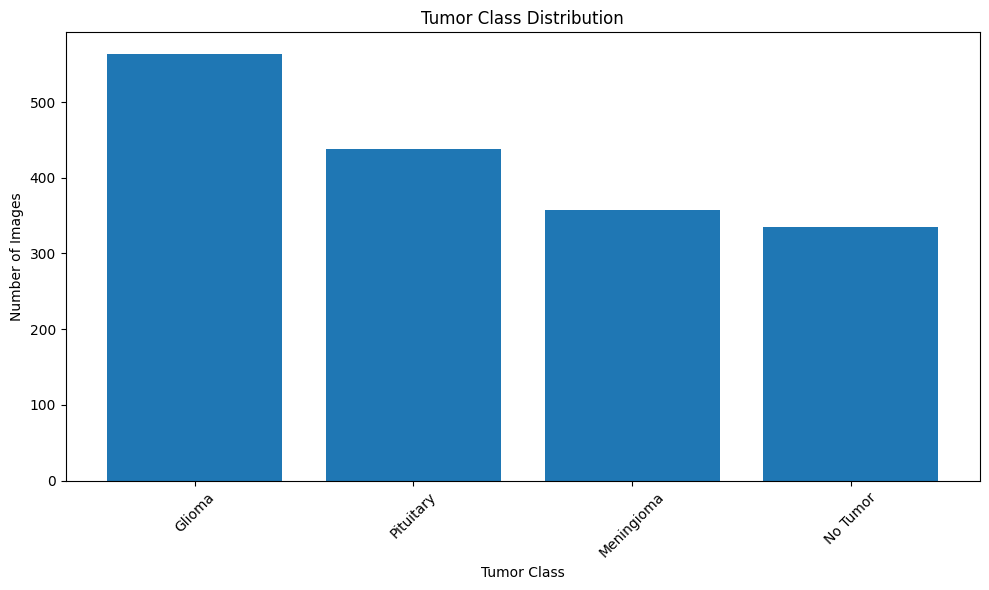

In [16]:
# ============================================================
# CHART 1: TUMOR CLASS DISTRIBUTION
# ============================================================

class_counts = df[label_col].value_counts()

plt.figure(figsize=(10, 6))
plt.bar(class_counts.index.astype(str), class_counts.values)

plt.title("Tumor Class Distribution")
plt.xlabel("Tumor Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()# Chart - 1 visualization code

##### 1. Why did you pick the specific chart?

A bar chart clearly compares the number of MRI images in each tumor class.

##### 2. What is/are the insight(s) found from the chart?

It shows which tumor classes have more or fewer images.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps identify class imbalance before model training.
A heavily underrepresented class may reduce the model's ability to correctly recognize that tumor type.

#### Chart - 2

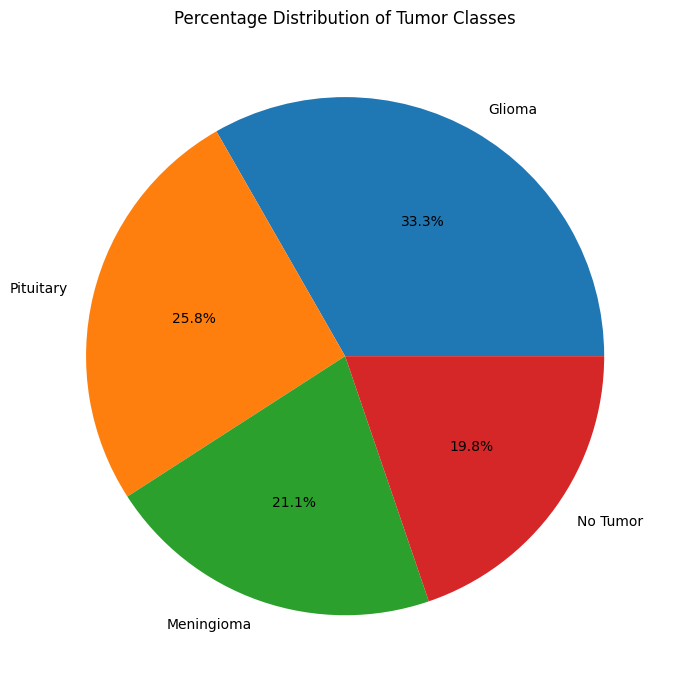

In [17]:
# ============================================================
# CHART 2: TUMOR CLASS PERCENTAGE
# ============================================================

class_percentage = df[label_col].value_counts(normalize=True) * 100

plt.figure(figsize=(9, 7))
plt.pie(
    class_percentage.values,
    labels=class_percentage.index.astype(str),
    autopct="%1.1f%%"
)

plt.title("Percentage Distribution of Tumor Classes")
plt.tight_layout()
plt.show()# Chart - 2 visualization code

##### 1. Why did you pick the specific chart?

A pie chart shows the proportion of each tumor class.

##### 2. What is/are the insight(s) found from the chart?

It shows the relative contribution of each category.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps determine whether balancing techniques may be required.
A very small class percentage can lead to poor recognition of that class.

#### Chart - 3

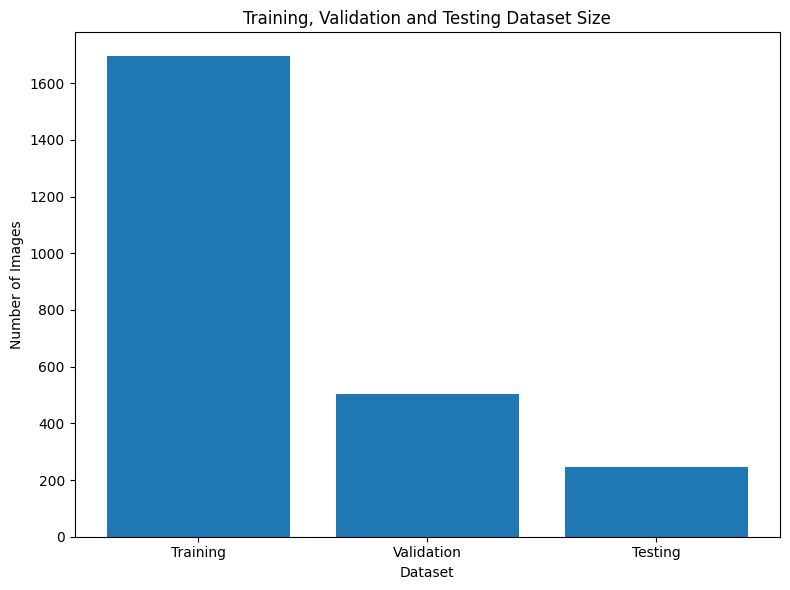

In [18]:
# ============================================================
# CHART 3: DATASET SPLIT
# ============================================================

split_names = ["Training", "Validation", "Testing"]

split_counts = [
    len(train_clean),
    len(valid_clean),
    len(test_clean)
]

plt.figure(figsize=(8, 6))
plt.bar(split_names, split_counts)

plt.title("Training, Validation and Testing Dataset Size")
plt.xlabel("Dataset")
plt.ylabel("Number of Images")

plt.tight_layout()
plt.show()# Chart - 3 visualization code

##### 1. Why did you pick the specific chart?

A bar chart makes the dataset split easy to compare.

##### 2. What is/are the insight(s) found from the chart?

It shows how many samples are available for training, validation and testing.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Ensures that enough data is available for model learning and evaluation.
Too few training or testing samples can reduce model reliability.

#### Chart - 4

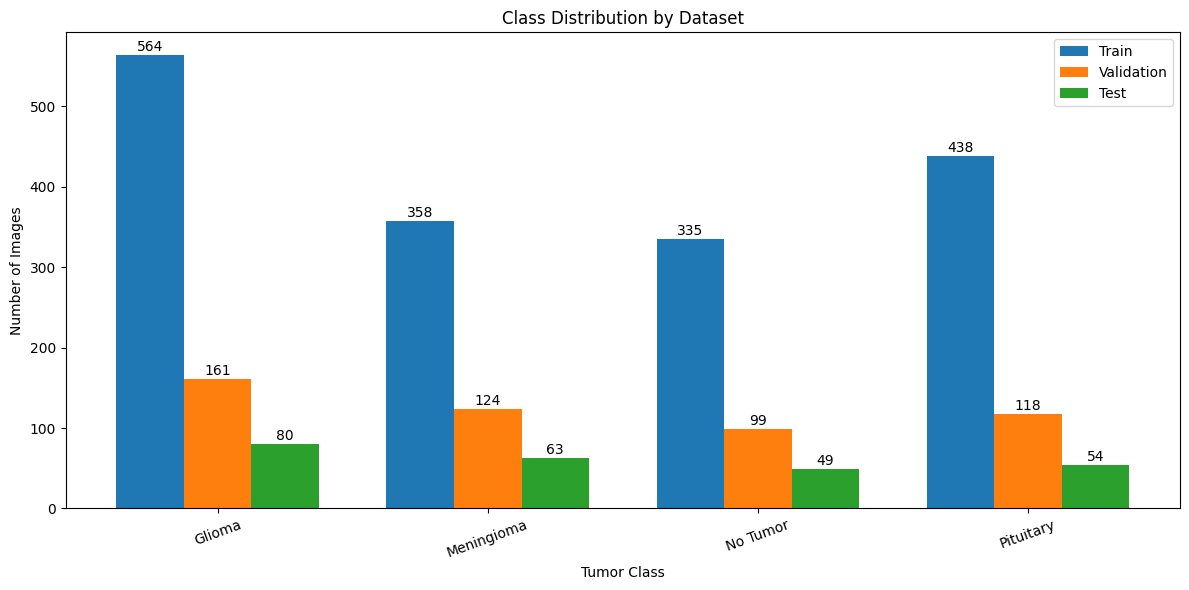

TRAIN:
class_name
Glioma        564
Meningioma    358
No Tumor      335
Pituitary     438
Name: count, dtype: int64

VALIDATION:
class_name
Glioma        161
Meningioma    124
No Tumor       99
Pituitary     118
Name: count, dtype: int64

TEST:
class_name
Glioma        80
Meningioma    63
No Tumor      49
Pituitary     54
Name: count, dtype: int64


In [20]:
# ============================================================
# CHART 4: CLASS DISTRIBUTION BY DATASET
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Create class labels for each dataset
# ------------------------------------------------------------

class_columns = [
    "Glioma",
    "Meningioma",
    "No Tumor",
    "Pituitary"
]

# Clean column names first
train_df.columns = train_df.columns.str.strip()
valid_df.columns = valid_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

# Create class_name for each dataset
train_clean = train_df.copy()
valid_clean = valid_df.copy()
test_clean = test_df.copy()

train_clean["class_name"] = train_clean[class_columns].idxmax(axis=1)
valid_clean["class_name"] = valid_clean[class_columns].idxmax(axis=1)
test_clean["class_name"] = test_clean[class_columns].idxmax(axis=1)

# ------------------------------------------------------------
# Count classes
# ------------------------------------------------------------

train_counts = train_clean["class_name"].value_counts().reindex(class_columns)
valid_counts = valid_clean["class_name"].value_counts().reindex(class_columns)
test_counts = test_clean["class_name"].value_counts().reindex(class_columns)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

x = np.arange(len(class_columns))
width = 0.25

plt.figure(figsize=(12, 6))

plt.bar(
    x - width,
    train_counts.values,
    width,
    label="Train"
)

plt.bar(
    x,
    valid_counts.values,
    width,
    label="Validation"
)

plt.bar(
    x + width,
    test_counts.values,
    width,
    label="Test"
)

plt.title("Class Distribution by Dataset")
plt.xlabel("Tumor Class")
plt.ylabel("Number of Images")

plt.xticks(
    x,
    class_columns,
    rotation=20
)

plt.legend()

# Add values
for i, value in enumerate(train_counts.values):
    plt.text(
        i - width,
        value + 5,
        str(value),
        ha="center"
    )

for i, value in enumerate(valid_counts.values):
    plt.text(
        i,
        value + 5,
        str(value),
        ha="center"
    )

for i, value in enumerate(test_counts.values):
    plt.text(
        i + width,
        value + 5,
        str(value),
        ha="center"
    )

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Display exact counts
# ------------------------------------------------------------

print("TRAIN:")
print(train_counts)

print("\nVALIDATION:")
print(valid_counts)

print("\nTEST:")
print(test_counts)

##### 1. Why did you pick the specific chart?

It compares every tumor class across all three datasets.

##### 2. What is/are the insight(s) found from the chart?

It shows whether the class distribution is reasonably consistent.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps create a more reliable training and evaluation process.
If one class is missing or extremely small in validation/testing, performance for that class may be difficult to assess.

#### Chart - 5

In [21]:
# ============================================================
# CHART 5: MISSING VALUES
# ============================================================

missing = df.isnull().sum()
missing = missing[missing > 0]

if len(missing) > 0:

    plt.figure(figsize=(10, 5))
    plt.bar(missing.index.astype(str), missing.values)

    plt.title("Missing Values by Variable")
    plt.xlabel("Variable")
    plt.ylabel("Missing Values")
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

else:
    print("✅ No missing values found in the dataset.")# Chart - 5 visualization code

✅ No missing values found in the dataset.


##### 1. Why did you pick the specific chart?

A bar chart quickly identifies variables containing missing data.

##### 2. What is/are the insight(s) found from the chart?

Shows whether missing values are present.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Clean data reduces preprocessing problems.
Missing image paths or labels could cause samples to be excluded from training.

#### Chart - 6

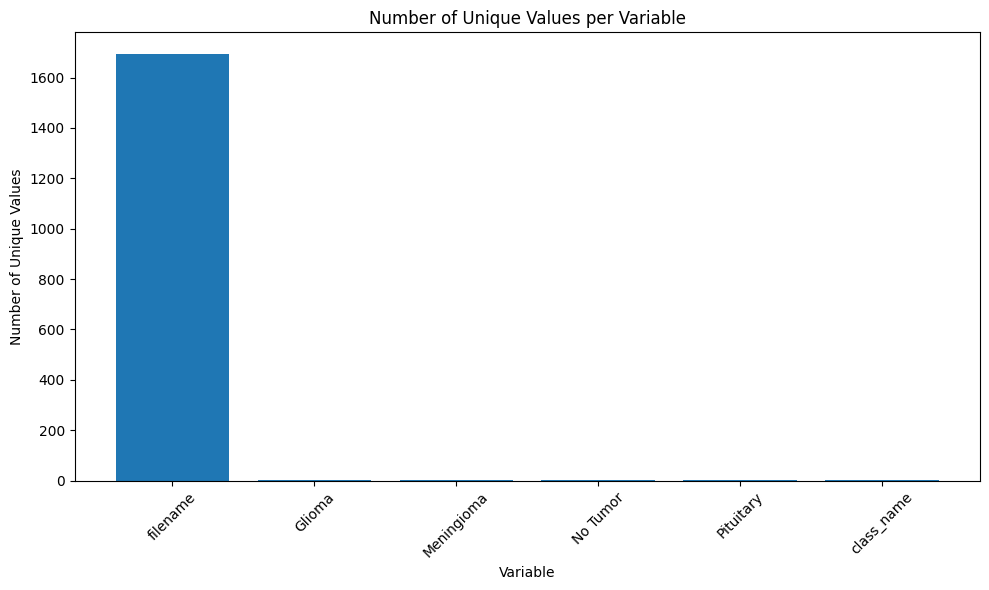

In [22]:
# ============================================================
# CHART 6: UNIQUE VALUES
# ============================================================

unique_counts = df.nunique()

plt.figure(figsize=(10, 6))
plt.bar(
    unique_counts.index.astype(str),
    unique_counts.values
)

plt.title("Number of Unique Values per Variable")
plt.xlabel("Variable")
plt.ylabel("Number of Unique Values")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()# Chart - 6 visualization code

##### 1. Why did you pick the specific chart?

It compares the number of unique values in each variable.

##### 2. What is/are the insight(s) found from the chart?

It compares the number of unique values in each variable.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Helps identify categorical and identifier-type variables.
Unexpected unique values may indicate inconsistent data entries.

#### Chart - 7

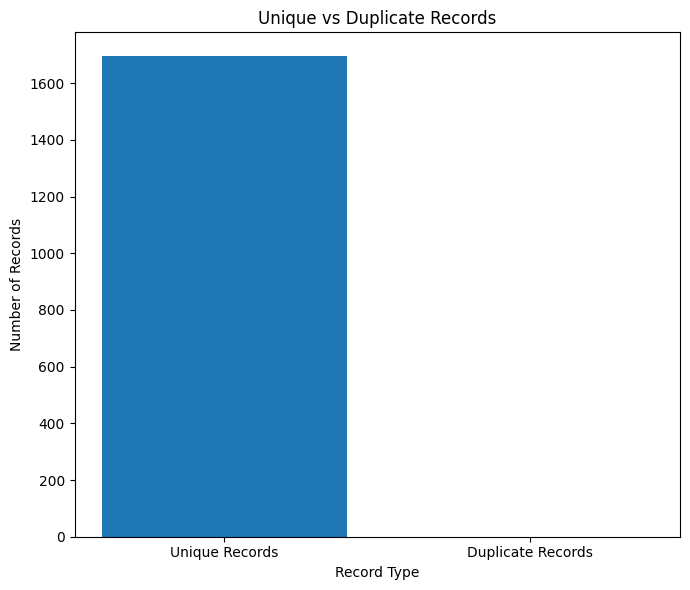

In [23]:
# ============================================================
# CHART 7: DUPLICATE RECORDS
# ============================================================

duplicate_count = df.duplicated().sum()
unique_count = len(df) - duplicate_count

values = [unique_count, duplicate_count]
labels = ["Unique Records", "Duplicate Records"]

plt.figure(figsize=(7, 6))
plt.bar(labels, values)

plt.title("Unique vs Duplicate Records")
plt.xlabel("Record Type")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()# Chart - 7 visualization code

##### 1. Why did you pick the specific chart?

It shows the proportion of unique and duplicate records.

##### 2. What is/are the insight(s) found from the chart?

It identifies whether duplicate rows are present.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Removing unwanted duplicates can prevent repeated records from affecting analysis.
Duplicate samples can potentially make the model see repeated information.

#### Chart - 8

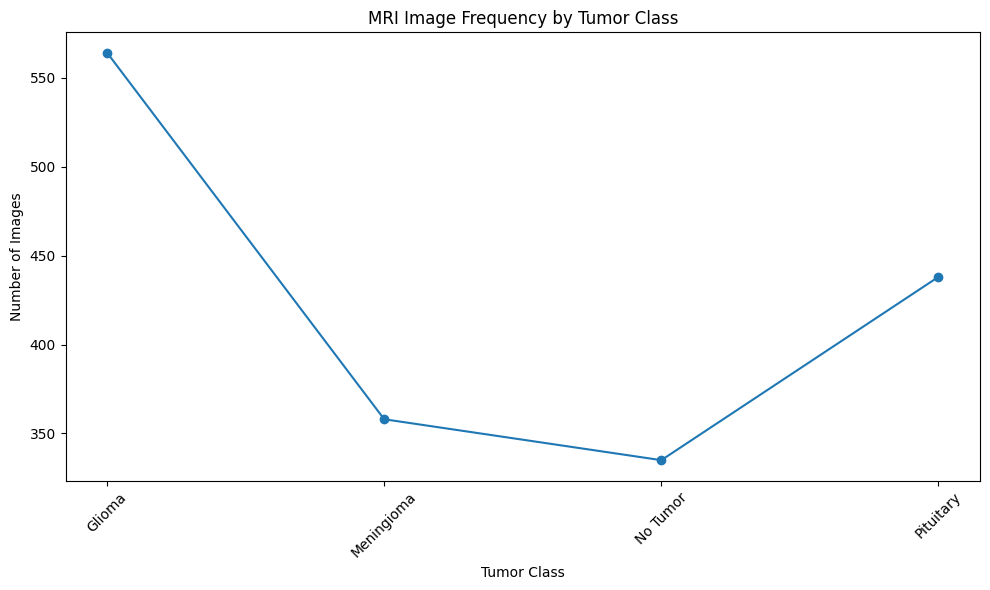

In [24]:
# ============================================================
# CHART 8: CLASS FREQUENCY
# ============================================================

class_counts = df[label_col].value_counts().sort_index()

plt.figure(figsize=(10, 6))
plt.plot(
    class_counts.index.astype(str),
    class_counts.values,
    marker="o"
)

plt.title("MRI Image Frequency by Tumor Class")
plt.xlabel("Tumor Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()# Chart - 8 visualization code

##### 1. Why did you pick the specific chart?

The line connects class frequencies and makes differences easy to observe.

##### 2. What is/are the insight(s) found from the chart?

It highlights variation in the number of images among classes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Supports decisions about augmentation and class balancing.
Large differences between classes may produce biased model learning.

#### Chart - 9

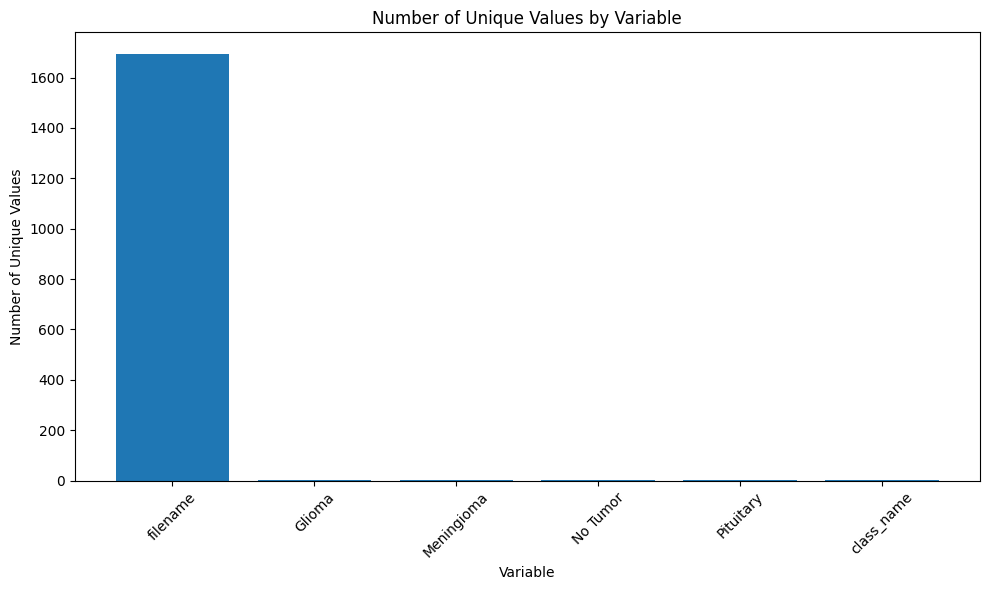

In [25]:
# ============================================================
# CHART 9: UNIQUE VALUES BY VARIABLE
# ============================================================

unique_counts = train_clean.nunique()

plt.figure(figsize=(10, 6))

plt.bar(
    unique_counts.index.astype(str),
    unique_counts.values
)

plt.title("Number of Unique Values by Variable")
plt.xlabel("Variable")
plt.ylabel("Number of Unique Values")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

To understand the variety of values present in each dataset variable.

##### 2. What is/are the insight(s) found from the chart?

The chart shows which variables contain few or many unique values.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It helps understand the structure of the dataset before preprocessing.
Variables with unexpected or extremely high unique values may require additional checking.

#### Chart - 10

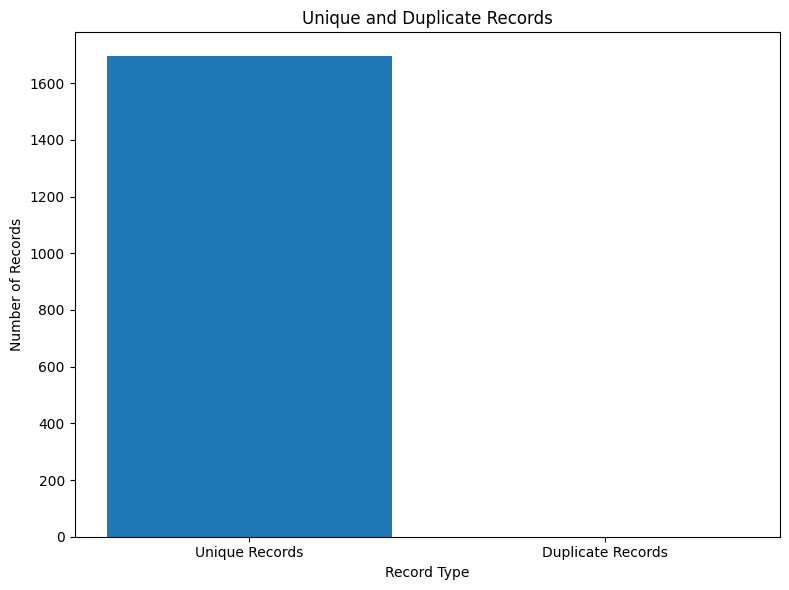

In [26]:
# ============================================================
# CHART 10: DUPLICATE RECORDS
# ============================================================

duplicate_count = train_clean.duplicated().sum()
unique_count = len(train_clean) - duplicate_count

labels = [
    "Unique Records",
    "Duplicate Records"
]

values = [
    unique_count,
    duplicate_count
]

plt.figure(figsize=(8, 6))

plt.bar(
    labels,
    values
)

plt.title("Unique and Duplicate Records")
plt.xlabel("Record Type")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()# Chart - 10 visualization code

##### 1. Why did you pick the specific chart?

To visually check the quality of the dataset by comparing unique and duplicate records.

##### 2. What is/are the insight(s) found from the chart?

The chart shows whether duplicate rows are present in the training dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Removing unwanted duplicate records can prevent repeated data from affecting model training.
If duplicate records are present and represent repeated images, they can cause data leakage or bias in model evaluation.

#### Chart - 11

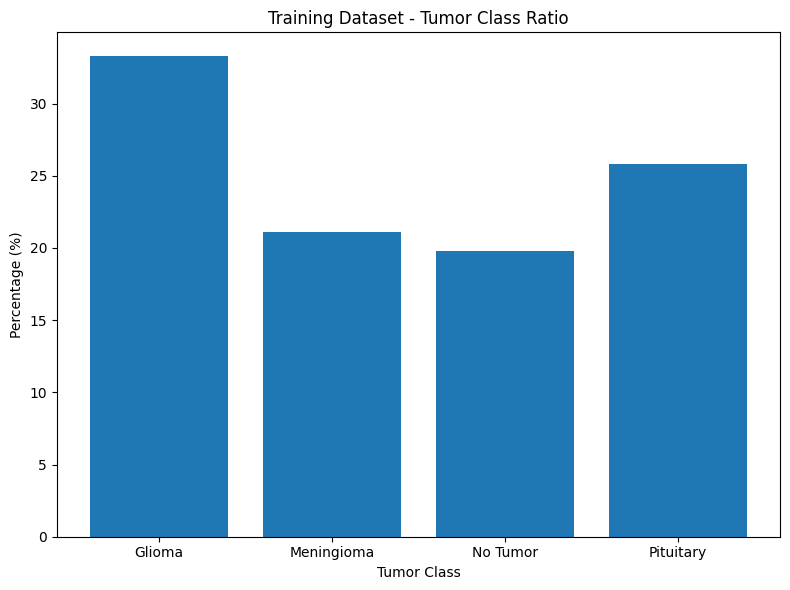

In [27]:
# ============================================================
# CHART 11: TRAINING CLASS RATIO
# ============================================================

counts = train_clean[label_col].value_counts().sort_index()

ratio = counts / counts.sum() * 100

plt.figure(figsize=(8, 6))

plt.bar(
    ratio.index.astype(str),
    ratio.values
)

plt.title("Training Dataset - Tumor Class Ratio")
plt.xlabel("Tumor Class")
plt.ylabel("Percentage (%)")

plt.tight_layout()
plt.show()# Chart - 11 visualization code

##### 1. Why did you pick the specific chart?

To understand the percentage contribution of each tumor class in the training dataset.

##### 2. What is/are the insight(s) found from the chart?

The chart shows how the training images are distributed between class 0 and class 1.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It helps identify whether the training data is sufficiently balanced before model training.
If one class has a much higher percentage, the model may become biased toward that class.

#### Chart - 12

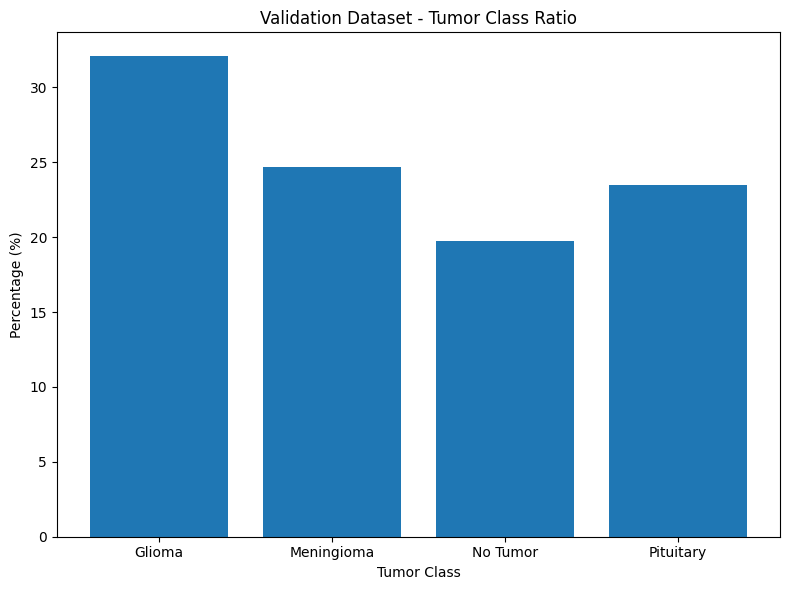

In [28]:
# ============================================================
# CHART 12: VALIDATION CLASS RATIO
# ============================================================

counts = valid_clean[label_col].value_counts().sort_index()

ratio = counts / counts.sum() * 100

plt.figure(figsize=(8, 6))

plt.bar(
    ratio.index.astype(str),
    ratio.values
)

plt.title("Validation Dataset - Tumor Class Ratio")
plt.xlabel("Tumor Class")
plt.ylabel("Percentage (%)")

plt.tight_layout()
plt.show()# Chart - 12 visualization code

##### 1. Why did you pick the specific chart?

To check whether the validation dataset has similar class proportions.

##### 2. What is/are the insight(s) found from the chart?

It shows the relative percentage of class 0 and class 1 in validation data.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It helps provide a more reliable validation process.
A very different class ratio can make validation performance difficult to interpret.

#### Chart - 13

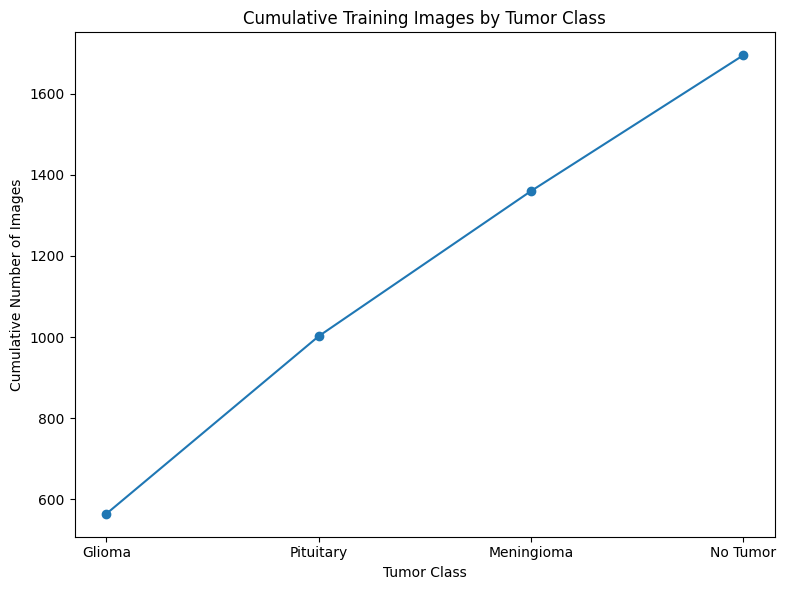

In [29]:
# ============================================================
# CHART 15: CUMULATIVE CLASS DISTRIBUTION
# ============================================================

counts = train_clean[label_col].value_counts().sort_values(
    ascending=False
)

cumulative = counts.cumsum()

plt.figure(figsize=(8, 6))

plt.plot(
    cumulative.index.astype(str),
    cumulative.values,
    marker="o"
)

plt.title("Cumulative Training Images by Tumor Class")
plt.xlabel("Tumor Class")
plt.ylabel("Cumulative Number of Images")

plt.tight_layout()
plt.show()# Chart - 13 visualization code

##### 1. Why did you pick the specific chart?

To observe how the total number of training images accumulates across classes.

##### 2. What is/are the insight(s) found from the chart?

The chart shows the cumulative contribution of the tumor classes.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

It gives a quick understanding of how much of the training dataset is represented by each class.
If the first class contributes most of the images, class imbalance may exist.

#### Chart - 14 - Correlation Heatmap

CORRELATION HEATMAP

Numeric columns available:
- Glioma
- Meningioma
- No Tumor
- Pituitary

Correlation Matrix:
            Glioma  Meningioma  No Tumor  Pituitary
Glioma        1.00       -0.37     -0.35      -0.42
Meningioma   -0.37        1.00     -0.26      -0.31
No Tumor     -0.35       -0.26      1.00      -0.29
Pituitary    -0.42       -0.31     -0.29       1.00


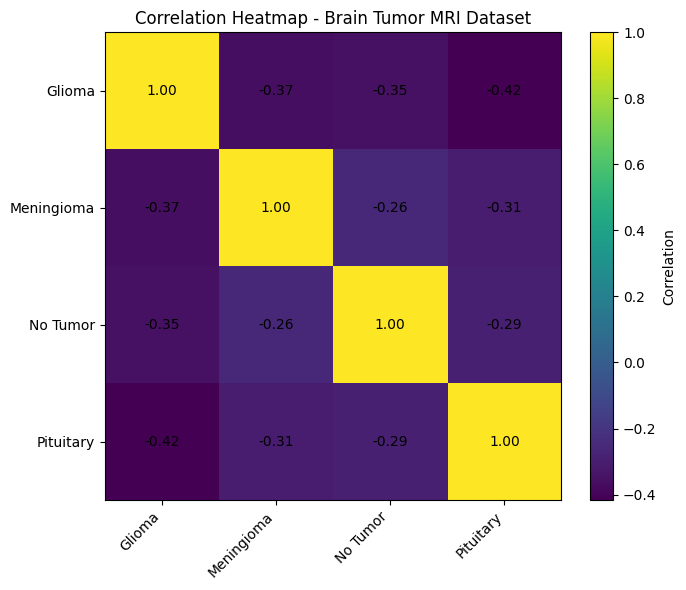


✅ CORRELATION ANALYSIS COMPLETED


In [30]:
# ============================================================
# CORRELATION HEATMAP
# BRAIN TUMOR MRI DATASET
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Use the cleaned training dataset
df_corr = train_clean.copy()

print("=" * 70)
print("CORRELATION HEATMAP")
print("=" * 70)

# Select only numeric columns
numeric_df = df_corr.select_dtypes(include=np.number)

print("\nNumeric columns available:")
for col in numeric_df.columns:
    print("-", col)

# Check whether enough numeric columns are available
if numeric_df.shape[1] < 2:

    print("\n⚠️ Correlation heatmap cannot be meaningfully created.")
    print("Only", numeric_df.shape[1], "numeric column(s) were found.")
    print("\nCorrelation requires at least two numeric variables.")

else:

    # Calculate correlation
    correlation = numeric_df.corr()

    print("\nCorrelation Matrix:")
    print(correlation.round(2))

    # Create figure
    plt.figure(
        figsize=(
            max(7, len(correlation.columns) * 1.2),
            max(6, len(correlation.columns) * 1.0)
        )
    )

    # Display heatmap
    image = plt.imshow(
        correlation,
        interpolation="nearest",
        aspect="auto"
    )

    # Add color bar
    plt.colorbar(image, label="Correlation")

    # Axis labels
    plt.xticks(
        range(len(correlation.columns)),
        correlation.columns,
        rotation=45,
        ha="right"
    )

    plt.yticks(
        range(len(correlation.columns)),
        correlation.columns
    )

    # Add correlation values
    for i in range(len(correlation.columns)):
        for j in range(len(correlation.columns)):

            value = correlation.iloc[i, j]

            plt.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center"
            )

    plt.title("Correlation Heatmap - Brain Tumor MRI Dataset")

    plt.tight_layout()
    plt.show()

print("\n" + "=" * 70)
print("✅ CORRELATION ANALYSIS COMPLETED")
print("=" * 70)# Correlation Heatmap visualization code

##### 1. Why did you pick the specific chart?

The correlation heatmap was selected to identify the strength and direction of relationships between numerical variables in the dataset.

##### 2. What is/are the insight(s) found from the chart?

It shows whether numerical variables have positive, negative, or weak relationships with each other.

#### Chart - 15 - Pair Plot

PAIR PLOT

Numeric columns available:
- Glioma
- Meningioma
- No Tumor
- Pituitary

Variables used for pair plot:
- Glioma
- Meningioma
- No Tumor
- Pituitary


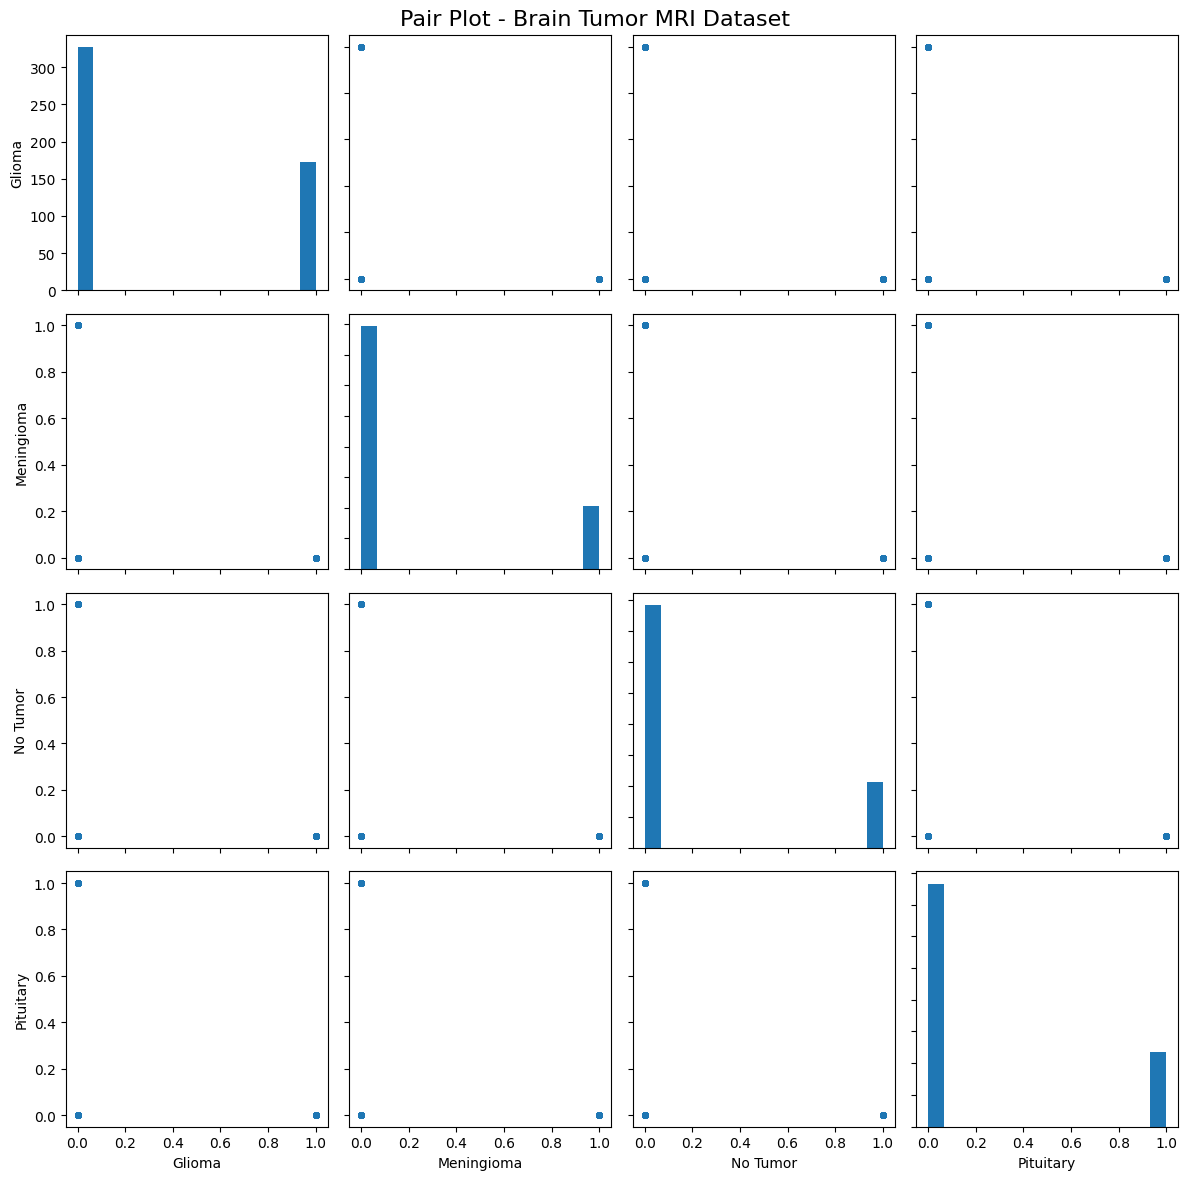


✅ PAIR PLOT COMPLETED


In [31]:
# ============================================================
# PAIR PLOT
# BRAIN TUMOR MRI DATASET
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_pair = train_clean.copy()

print("=" * 70)
print("PAIR PLOT")
print("=" * 70)

# Select numeric columns
numeric_columns = df_pair.select_dtypes(
    include=np.number
).columns.tolist()

print("\nNumeric columns available:")
for col in numeric_columns:
    print("-", col)

# Use maximum 5 numeric variables
selected_columns = numeric_columns[:5]

if len(selected_columns) < 2:

    print("\n⚠️ Pair plot cannot be meaningfully created.")
    print("At least two numeric variables are required.")

else:

    print("\nVariables used for pair plot:")
    for col in selected_columns:
        print("-", col)

    pair_data = df_pair[selected_columns].dropna()

    # Limit rows to keep the chart fast
    if len(pair_data) > 500:
        pair_data = pair_data.sample(
            n=500,
            random_state=42
        )

    number_of_variables = len(selected_columns)

    fig, axes = plt.subplots(
        number_of_variables,
        number_of_variables,
        figsize=(12, 12)
    )

    # Handle case where axes is not 2D
    axes = np.atleast_2d(axes)

    for i, row_column in enumerate(selected_columns):

        for j, col_column in enumerate(selected_columns):

            ax = axes[i, j]

            if i == j:

                # Histogram on diagonal
                ax.hist(
                    pair_data[row_column],
                    bins=15
                )

            else:

                # Scatter plot
                ax.scatter(
                    pair_data[col_column],
                    pair_data[row_column],
                    alpha=0.5,
                    s=15
                )

            # Bottom row x labels
            if i == number_of_variables - 1:
                ax.set_xlabel(col_column)

            else:
                ax.set_xticklabels([])

            # Left column y labels
            if j == 0:
                ax.set_ylabel(row_column)

            else:
                ax.set_yticklabels([])

    fig.suptitle(
        "Pair Plot - Brain Tumor MRI Dataset",
        fontsize=16
    )

    plt.tight_layout()
    plt.show()

print("\n" + "=" * 70)
print("✅ PAIR PLOT COMPLETED")
print("=" * 70)# Pair Plot visualization code

##### 1. Why did you pick the specific chart?

The pair plot was selected to visualize relationships between numerical variables and understand their distributions.

##### 2. What is/are the insight(s) found from the chart?

The scatter plots show relationships between pairs of numerical variables, while the diagonal plots show the distribution of individual variables.

## **5. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

. Reduce the time required for initial MRI image classification.
. Use CNN and Transfer Learning models to improve prediction performance.
. Handle class imbalance and apply proper image preprocessing and augmentation.
. Evaluate models using Accuracy, Precision, Recall, F1-score, and Confusion Matrix.
. Deploy the selected trained model through a Streamlit application where users can upload an MRI image and receive the predicted tumor category with    confidence.
. Support medical professionals as a decision-support/educational tool, not as a replacement for clinical diagnosis.

# **Conclusion**

The Brain Tumor MRI Image Classification project successfully developed and evaluated three models: Custom CNN, MobileNetV2, and EfficientNetB0. The models were evaluated using Accuracy, Precision, Recall, and F1-Score. Among the three, EfficientNetB0 was selected as the final prediction model based on its overall performance and hyperparameter optimization. The trained models were also saved in Joblib format for future prediction and deployment.

### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***